# Clustering de regiones — nueva zonificacion para el modelo jerarquico

**Objetivo:** en vez de usar las 3 Cordilleras (`Cordilleras.shp`) como zonas fijas del
modelo jerarquico (`05_modelo_jerarquico_cordilleras.ipynb`), se agrupan TODOS los pixeles
validos del area de estudio por similitud morfometrica (Altitud, Pendiente, Relieve
relativo) usando clustering **con restriccion de contigüidad espacial real**: cada celda
solo puede unirse a sus vecinas Norte/Sur/Este/Oeste (Rook).

Esto es distinto de `02_clustering_espacial_altiplanos.py`, donde los 491 poligonos de
altiplano NO son contiguos entre si y se necesito KNN/DistanceBand sobre los centroides
como sustituto de vecindad. Aqui si existe una grilla raster continua, asi que se puede
exigir contigüidad real sin necesidad de ese sustituto.

**Problema de escala:** hay ~24.8 millones de pixeles validos en la grilla de 50 m —
clustering jerarquico con restriccion de conectividad sobre esa cantidad de celdas es
computacionalmente intratable. Solucion: se agrega la grilla a una resolucion mas gruesa
(factor configurable, por defecto 20x -> 1 km/celda), se hace el clustering ahi, y el
resultado se reescala de vuelta a los 50 m originales para producir un raster de zonas
usable directamente como reemplazo de `zonas_cordilleras.tif` en el modelo jerarquico.

Se reutiliza la funcion `cortar_arbol_aglomerativo` (union-find) ya validada en
`02_clustering_espacial_altiplanos.py` y `06_mapas_clusters_n_mayor_3.py`: se ajusta el
arbol de Ward **una sola vez** y se corta para muchos valores de k sin recalcular.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize, shapes as rio_shapes
import geopandas as gpd
from shapely.geometry import shape as shapely_shape
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.feature_extraction.image import grid_to_graph
from scipy.cluster.hierarchy import dendrogram

t0_total = time.time()

CARPETA_RASTER = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Raster\50m_UTM\Analisis"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"
RUTA_CORDILLERAS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Cordilleras.shp"
RUTA_ALTIPLANOS = os.path.join(CARPETA_RASTER, "Altiplanos.tif")

RUTA_DEM = os.path.join(CARPETA_RASTER, "DEM_NA_50.tif")
RUTA_PENDIENTE = os.path.join(CARPETA_RASTER, "Pendiente.tif")
RUTA_RELIEVE = os.path.join(CARPETA_RASTER, "Relieve_Relativo.tif")

SEMILLA = 42
FACTOR_AGREGACION = 20   # 50 m -> 1000 m (1 km) por celda agregada
UMBRAL_VALIDEZ = 0.5     # fraccion minima de pixeles validos dentro del bloque para considerarlo valido
N_CLUSTERS_MINIMO = 4    # igual criterio que 06/07_mapas_clusters_n_mayor_3: k=2/3 no es geomorfologicamente util
RANGO_K = range(2, 21)   # numero de regiones candidatas a evaluar
TAMANO_MUESTRA_SS = 5000  # silhouette exacto es inviable con decenas de miles de celdas

np.random.seed(SEMILLA)
print("Constantes definidas.")

Constantes definidas.


## 1. Cargar rasters y verificar alineacion

`DEM_NA_50.tif`, `Pendiente.tif` y `Relieve_Relativo.tif` deben compartir exactamente la
misma grilla (mismo shape y transform) — a diferencia de `Altiplanos.tif` en el notebook
03, aqui no hace falta realinear nada.

In [2]:
def transform_coincide(t1, t2, tol=1e-6):
    return all(abs(a - b) < tol for a, b in zip(t1, t2))


with rasterio.open(RUTA_DEM) as src:
    dem = src.read(1).astype(np.float32)
    nodata_dem = src.nodata
    transform_original = src.transform
    crs_original = src.crs
    perfil_original = src.profile.copy()

with rasterio.open(RUTA_PENDIENTE) as src:
    assert src.shape == dem.shape and transform_coincide(src.transform, transform_original), \
        "Pendiente no esta alineada con el DEM"
    pendiente = src.read(1).astype(np.float32)
    nodata_pendiente = src.nodata

with rasterio.open(RUTA_RELIEVE) as src:
    assert src.shape == dem.shape and transform_coincide(src.transform, transform_original), \
        "Relieve no esta alineado con el DEM"
    relieve = src.read(1).astype(np.float32)
    nodata_relieve = src.nodata

mascara_valida = (
    (dem != nodata_dem) &
    (pendiente != nodata_pendiente) &
    (relieve != nodata_relieve)
)

print(f"Grilla original: {dem.shape} = {dem.size:,} pixeles")
print(f"Pixeles validos (DEM + Pendiente + Relieve): {mascara_valida.sum():,} ({mascara_valida.mean()*100:.1f}%)")

Grilla original: (8276, 6084) = 50,351,184 pixeles
Pixeles validos (DEM + Pendiente + Relieve): 24,783,966 (49.2%)


## 2. Agregar a grilla gruesa (50 m -> 1 km)

Cada celda agregada se calcula como el promedio de los pixeles validos dentro de su
bloque de `FACTOR_AGREGACION x FACTOR_AGREGACION` pixeles originales. Una celda agregada
se considera valida si al menos `UMBRAL_VALIDEZ` (50%) de sus pixeles originales lo son.
La grilla se recorta al multiplo exacto de `FACTOR_AGREGACION` mas cercano (perdida
marginal de unas pocas filas/columnas en el borde).

In [3]:
def recortar(matriz, factor):
    filas, columnas = matriz.shape
    fr = (filas // factor) * factor
    cr = (columnas // factor) * factor
    return matriz[:fr, :cr], fr, cr


def a_bloques(matriz_recortada, factor):
    fr, cr = matriz_recortada.shape
    return matriz_recortada.reshape(fr // factor, factor, cr // factor, factor)


mascara_rec, filas_rec, cols_rec = recortar(mascara_valida, FACTOR_AGREGACION)
mascara_bloques = a_bloques(mascara_rec, FACTOR_AGREGACION)
conteo_validos = mascara_bloques.sum(axis=(1, 3))
fraccion_valida_celda = conteo_validos / (FACTOR_AGREGACION ** 2)


def promedio_por_bloque(matriz, factor, filas_rec, cols_rec, mascara_bloques, conteo_validos):
    matriz_rec = matriz[:filas_rec, :cols_rec]
    bloques = a_bloques(matriz_rec, factor)
    suma = np.where(mascara_bloques, bloques, 0).sum(axis=(1, 3))
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(conteo_validos > 0, suma / np.maximum(conteo_validos, 1), np.nan)


dem_agg = promedio_por_bloque(dem, FACTOR_AGREGACION, filas_rec, cols_rec, mascara_bloques, conteo_validos)
pendiente_agg = promedio_por_bloque(pendiente, FACTOR_AGREGACION, filas_rec, cols_rec, mascara_bloques, conteo_validos)
relieve_agg = promedio_por_bloque(relieve, FACTOR_AGREGACION, filas_rec, cols_rec, mascara_bloques, conteo_validos)

mascara_agg_valida = fraccion_valida_celda >= UMBRAL_VALIDEZ

print(f"Grilla agregada ({FACTOR_AGREGACION}x = {FACTOR_AGREGACION*50} m/celda): {dem_agg.shape} = "
      f"{dem_agg.size:,} celdas (recorte de {dem.shape} a {(filas_rec, cols_rec)} pixeles originales)")
print(f"Celdas agregadas validas (fraccion >= {UMBRAL_VALIDEZ}): {mascara_agg_valida.sum():,} "
      f"({mascara_agg_valida.mean()*100:.1f}%)")

Grilla agregada (20x = 1000 m/celda): (413, 304) = 125,552 celdas (recorte de (8276, 6084) a (8260, 6080) pixeles originales)
Celdas agregadas validas (fraccion >= 0.5): 61,950 (49.3%)


## 3. Estandarizar variables y construir el grafo de contigüidad (Rook)

`grid_to_graph` conecta cada celda valida solo con sus vecinas Norte/Sur/Este/Oeste
dentro de la mascara — a diferencia de KNN/DistanceBand (script 02), esto es contigüidad
real, no un sustituto basado en distancia entre centroides.

In [4]:
filas_agg, columnas_agg = dem_agg.shape
indices_validos = np.flatnonzero(mascara_agg_valida.ravel())

X_completo = np.column_stack([dem_agg.ravel(), pendiente_agg.ravel(), relieve_agg.ravel()])
X = X_completo[indices_validos]

escalador = StandardScaler()
X_std = escalador.fit_transform(X)

grafo_conectividad = grid_to_graph(*mascara_agg_valida.shape, mask=mascara_agg_valida)
assert grafo_conectividad.shape[0] == X_std.shape[0], "El grafo y la matriz de features no coinciden en tamano"
simetrico = (grafo_conectividad != grafo_conectividad.T).nnz == 0

print(f"Celdas agregadas validas usadas en el clustering: {X_std.shape[0]:,}")
print(f"Grafo de conectividad (Rook, 4-vecinos): {grafo_conectividad.shape}, "
      f"{grafo_conectividad.nnz:,} conexiones, simetrico={simetrico}")

Celdas agregadas validas usadas en el clustering: 61,950
Grafo de conectividad (Rook, 4-vecinos): (61950, 61950), 307,670 conexiones, simetrico=True


## 4. Ajustar el arbol de Ward una sola vez y validar el corte

Se reutiliza `cortar_arbol_aglomerativo` (union-find), ya validada con ARI=1.000 en
`02_clustering_espacial_altiplanos.py`. Aqui se repite la misma validacion con un k de
prueba antes de confiar en el barrido completo de k.

In [5]:
def cortar_arbol_aglomerativo(children, n_muestras, n_clusters):
    padre = list(range(2 * n_muestras - 1))

    def encontrar(x):
        while padre[x] != x:
            padre[x] = padre[padre[x]]
            x = padre[x]
        return x

    def unir(x, y):
        rx, ry = encontrar(x), encontrar(y)
        if rx != ry:
            padre[ry] = rx

    n_fusiones = n_muestras - n_clusters
    for i in range(n_fusiones):
        a, b = int(children[i, 0]), int(children[i, 1])
        unir(a, b)
        unir(a, n_muestras + i)

    raices = np.array([encontrar(j) for j in range(n_muestras)])
    _, etiquetas = np.unique(raices, return_inverse=True)
    return etiquetas


t0 = time.time()
modelo_arbol = AgglomerativeClustering(
    n_clusters=2, linkage="ward", connectivity=grafo_conectividad,
    compute_full_tree=True, compute_distances=True,
).fit(X_std)
print(f"Arbol de Ward ajustado en {time.time()-t0:.1f}s sobre {X_std.shape[0]:,} celdas")
print(f"Componentes conectados del grafo: {modelo_arbol.n_connected_components_}")

n_muestras = X_std.shape[0]

etiquetas_corte_prueba = cortar_arbol_aglomerativo(modelo_arbol.children_, n_muestras, 5)
etiquetas_directas_prueba = AgglomerativeClustering(
    n_clusters=5, linkage="ward", connectivity=grafo_conectividad
).fit_predict(X_std)
ari_validacion = adjusted_rand_score(etiquetas_corte_prueba, etiquetas_directas_prueba)
print(f"Validacion del corte (k=5): ARI contra ajuste directo = {ari_validacion:.3f}")
assert ari_validacion > 0.999, "El corte del arbol no coincide con el ajuste directo"


Arbol de Ward ajustado en 2.4s sobre 61,950 celdas
Componentes conectados del grafo: 1


Validacion del corte (k=5): ARI contra ajuste directo = 1.000


## 5. Barrido de k (numero de regiones)

Silhouette (SS) se calcula sobre una muestra de 5,000 celdas (a diferencia de los scripts
01/02/06 con solo 491 poligonos, aqui el silhouette exacto sobre decenas de miles de
celdas es computacionalmente inviable). Calinski-Harabasz (CH) se calcula exacto (barato,
basado en centroides).

k= 2  SS=0.191  CH= 15082.5  inercia=    149460.7


k= 3  SS=-0.005  CH= 15783.4  inercia=    123114.0


k= 4  SS=0.065  CH= 17869.6  inercia=     99629.6


k= 5  SS=0.008  CH= 15461.5  inercia=     92999.3


k= 6  SS=0.011  CH= 13426.9  inercia=     89188.1


...

k=16  SS=-0.107  CH=  7363.2  inercia=     66772.9


k=17  SS=-0.122  CH=  7144.0  inercia=     65311.5


k=18  SS=-0.125  CH=  6900.9  inercia=     64213.5


k=19  SS=-0.127  CH=  6611.5  inercia=     63612.5


k=20  SS=-0.125  CH=  6416.7  inercia=     62604.4


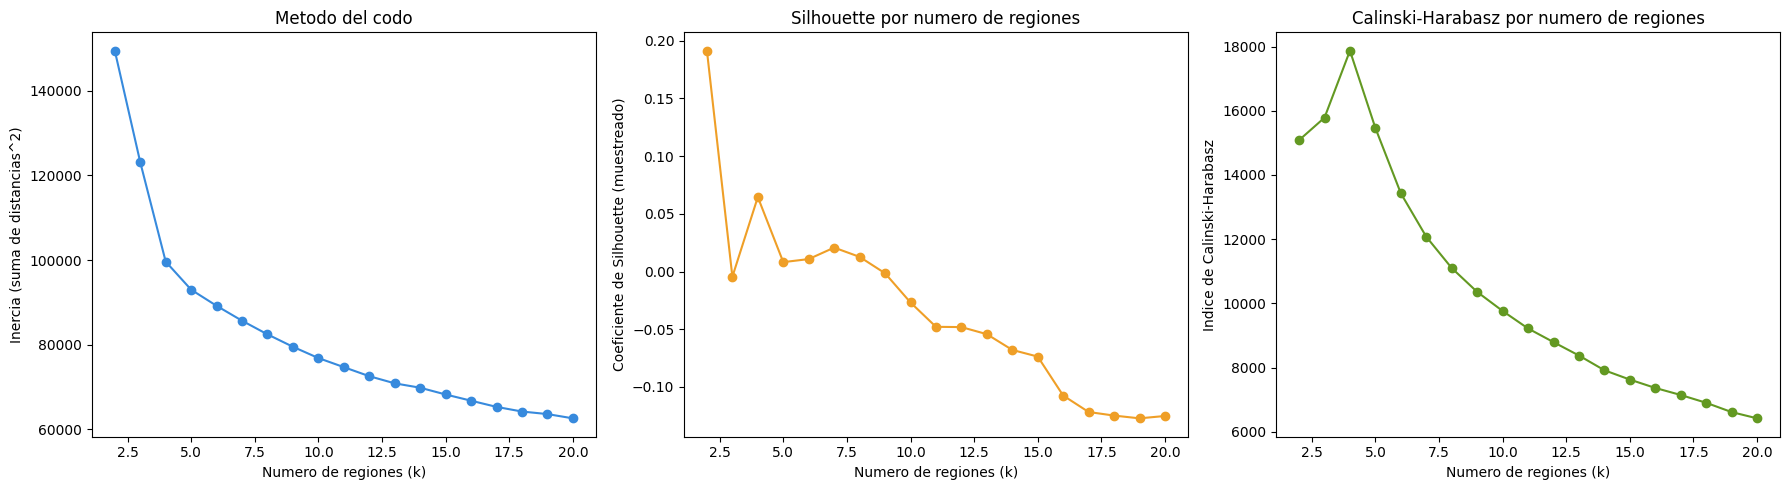

In [6]:
resultados_k = []
for k in RANGO_K:
    etiquetas_k = cortar_arbol_aglomerativo(modelo_arbol.children_, n_muestras, k)
    ss_k = silhouette_score(X_std, etiquetas_k, sample_size=TAMANO_MUESTRA_SS, random_state=SEMILLA)
    ch_k = calinski_harabasz_score(X_std, etiquetas_k)
    inercia_k = sum(
        ((X_std[etiquetas_k == c] - X_std[etiquetas_k == c].mean(axis=0)) ** 2).sum()
        for c in np.unique(etiquetas_k)
    )
    resultados_k.append((k, ss_k, ch_k, inercia_k))
    print(f"k={k:2d}  SS={ss_k:.3f}  CH={ch_k:8.1f}  inercia={inercia_k:12.1f}")

k_vals, ss_vals, ch_vals, inercia_vals = zip(*resultados_k)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.plot(k_vals, inercia_vals, "o-", color="#378ADD")
ax1.set_title("Metodo del codo")
ax1.set_xlabel("Numero de regiones (k)")
ax1.set_ylabel("Inercia (suma de distancias^2)")

ax2.plot(k_vals, ss_vals, "o-", color="#EF9F27")
ax2.set_title("Silhouette por numero de regiones")
ax2.set_xlabel("Numero de regiones (k)")
ax2.set_ylabel("Coeficiente de Silhouette (muestreado)")

ax3.plot(k_vals, ch_vals, "o-", color="#639922")
ax3.set_title("Calinski-Harabasz por numero de regiones")
ax3.set_xlabel("Numero de regiones (k)")
ax3.set_ylabel("Indice de Calinski-Harabasz")

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_RESULTADOS, "22_seleccion_k_regiones.png"), dpi=150)
plt.show()

## 6. Elegir el numero optimo de regiones

Igual que en `06_mapas_clusters_n_mayor_3.py`: se restringe la busqueda a
`k >= N_CLUSTERS_MINIMO` porque un numero muy bajo de regiones (2-3) no mejora nada sobre
las 3 Cordilleras que ya existen — el objetivo de este notebook es una zonificacion **mas
informativa**, no una mas simple.

In [7]:
mejor_k_sin_restriccion = k_vals[int(np.argmax(ss_vals))]
candidatos_validos = [(k, ss) for k, ss in zip(k_vals, ss_vals) if k >= N_CLUSTERS_MINIMO]
mejor_k_restringido, mejor_ss_restringido = max(candidatos_validos, key=lambda par: par[1])
mejor_k_ch = k_vals[int(np.argmax(ch_vals))]

print(f"Mejor k por SS (sin restriccion): k={mejor_k_sin_restriccion} (SS={max(ss_vals):.3f})")
print(f"Mejor k por SS (k>={N_CLUSTERS_MINIMO}, mismo criterio que 06/07_..._n_mayor_3): "
      f"k={mejor_k_restringido} (SS={mejor_ss_restringido:.3f})")
print(f"Mejor k por CH (sin restriccion): k={mejor_k_ch} (CH={max(ch_vals):.1f})")

K_REGIONES = mejor_k_restringido
etiquetas_finales = cortar_arbol_aglomerativo(modelo_arbol.children_, n_muestras, K_REGIONES)
print(f"\nK_REGIONES elegido = {K_REGIONES}")

Mejor k por SS (sin restriccion): k=2 (SS=0.191)
Mejor k por SS (k>=4, mismo criterio que 06/07_..._n_mayor_3): k=4 (SS=0.065)
Mejor k por CH (sin restriccion): k=4 (CH=17869.6)

K_REGIONES elegido = 4


## 6b. Graficas de diagnostico individuales (carpeta `Clustering_Regiones/`)

Ademas de la figura combinada `22_seleccion_k_regiones.png`, se generan versiones
individuales del codo, el Silhouette y un dendrograma truncado (el arbol completo tiene
61,950 hojas — imposible de graficar entero — asi que se muestran solo las ultimas 40
fusiones, que son justamente las que definen los cortes de k bajo como el elegido). Estas
figuras se guardan en una subcarpeta `Resultados\Clustering_Regiones\` dedicada a este
notebook, separada de las figuras numeradas del resto del proyecto.

Carpeta de figuras de este notebook: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\Clustering_Regiones


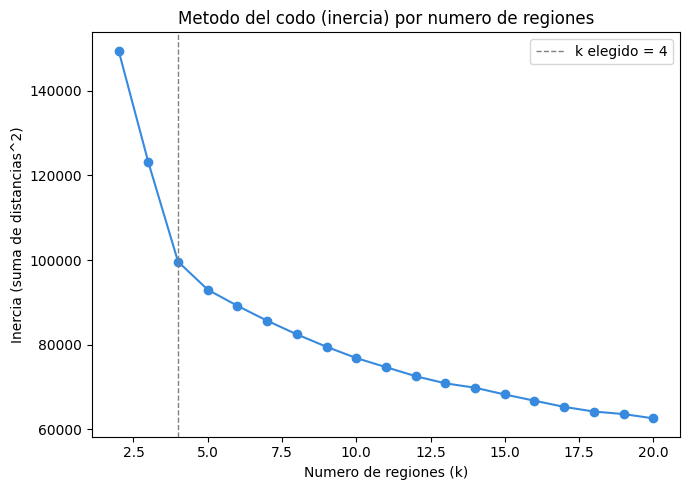

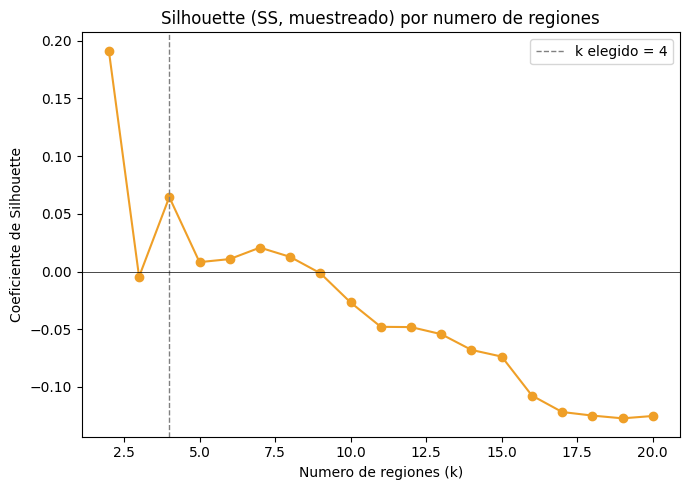

In [8]:
CARPETA_FIGURAS_NB = os.path.join(CARPETA_RESULTADOS, "Clustering_Regiones")
os.makedirs(CARPETA_FIGURAS_NB, exist_ok=True)
print(f"Carpeta de figuras de este notebook: {CARPETA_FIGURAS_NB}")

# --- Codo (inercia) individual ---
plt.figure(figsize=(7, 5))
plt.plot(k_vals, inercia_vals, "o-", color="#378ADD")
plt.axvline(K_REGIONES, color="gray", linestyle="--", linewidth=1,
            label=f"k elegido = {K_REGIONES}")
plt.title("Metodo del codo (inercia) por numero de regiones")
plt.xlabel("Numero de regiones (k)")
plt.ylabel("Inercia (suma de distancias^2)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS_NB, "01_codo_inercia.png"), dpi=150)
plt.show()

# --- Silhouette (SS) individual ---
plt.figure(figsize=(7, 5))
plt.plot(k_vals, ss_vals, "o-", color="#EF9F27")
plt.axvline(K_REGIONES, color="gray", linestyle="--", linewidth=1,
            label=f"k elegido = {K_REGIONES}")
plt.axhline(0, color="black", linewidth=0.5)
plt.title("Silhouette (SS, muestreado) por numero de regiones")
plt.xlabel("Numero de regiones (k)")
plt.ylabel("Coeficiente de Silhouette")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS_NB, "02_silhouette_vs_k.png"), dpi=150)
plt.show()

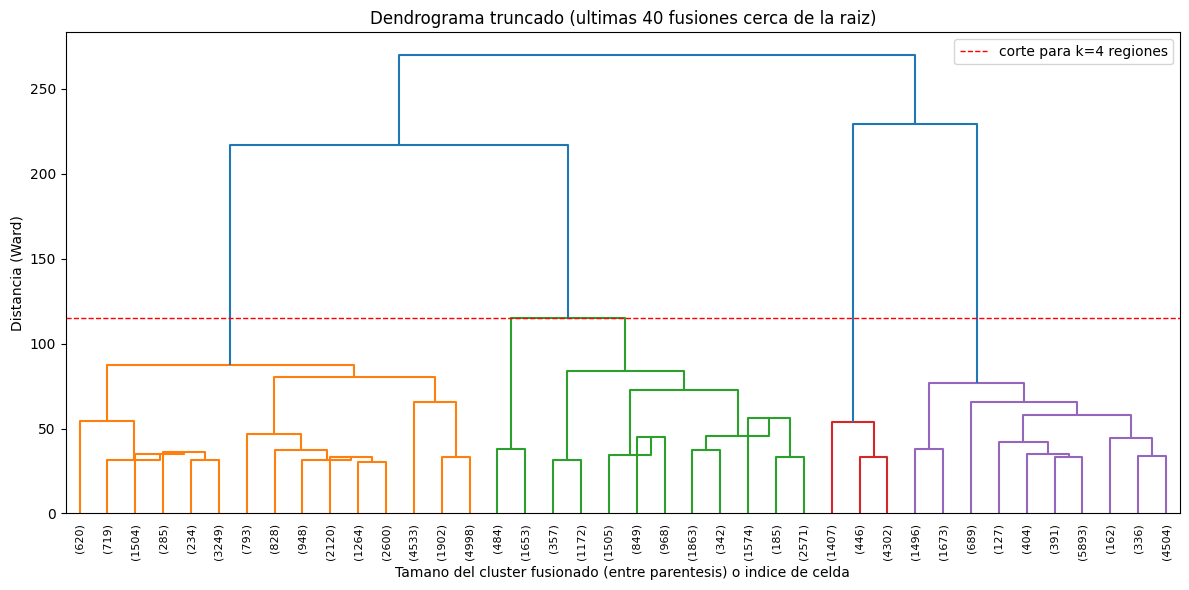

In [9]:
# --- Dendrograma truncado (ultimas 40 fusiones, cerca de la raiz) ---
# Construccion estandar de la matriz de enlace Z a partir de un AgglomerativeClustering
# con compute_distances=True (children_ + distances_ + conteo de hojas por nodo).
conteos_por_nodo = np.zeros(modelo_arbol.children_.shape[0])
for i, fusion in enumerate(modelo_arbol.children_):
    conteo_actual = 0
    for hijo in fusion:
        if hijo < n_muestras:
            conteo_actual += 1
        else:
            conteo_actual += conteos_por_nodo[hijo - n_muestras]
    conteos_por_nodo[i] = conteo_actual

Z = np.column_stack([modelo_arbol.children_, modelo_arbol.distances_, conteos_por_nodo]).astype(float)

# altura a la que se corta el arbol para obtener exactamente K_REGIONES clusters
altura_corte = Z[n_muestras - K_REGIONES - 1, 2]

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="lastp", p=40, show_leaf_counts=True, leaf_rotation=90)
plt.axhline(altura_corte, color="red", linestyle="--", linewidth=1,
            label=f"corte para k={K_REGIONES} regiones")
plt.title("Dendrograma truncado (ultimas 40 fusiones cerca de la raiz)")
plt.xlabel("Tamano del cluster fusionado (entre parentesis) o indice de celda")
plt.ylabel("Distancia (Ward)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS_NB, "03_dendrograma.png"), dpi=150)
plt.show()

## 6c. Mapas con el k optimo y con un k mayor a 10

Se guarda una copia del mapa con `K_REGIONES` (el optimo, k=4 segun el barrido) y un
segundo mapa con un numero de regiones bastante mayor (`K_REGIONES_MAYOR`, k>10) para
comparar visualmente que tan distinta se ve la zonificacion al forzar mas granularidad
de la que sugieren SS/CH.

K_REGIONES_MAYOR = 15  (SS=-0.074, CH=7624.2)


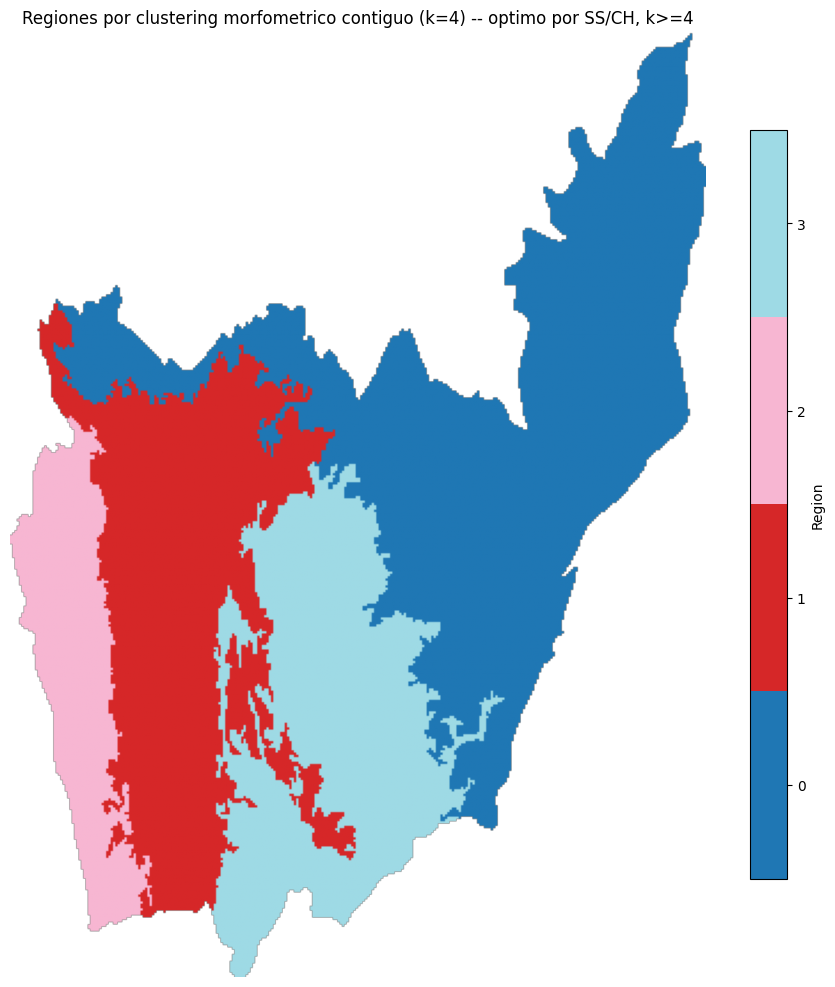

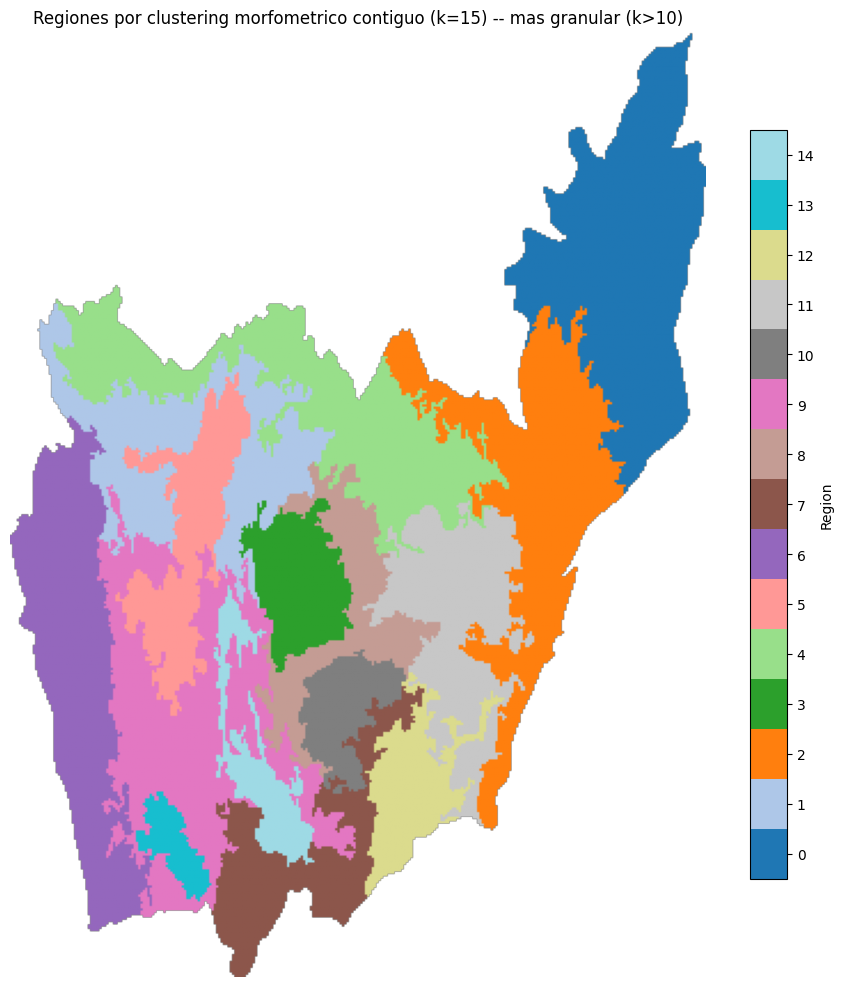

In [10]:
K_REGIONES_MAYOR = 15  # k > 10, ya evaluado dentro de RANGO_K (2..20)
etiquetas_mayor = cortar_arbol_aglomerativo(modelo_arbol.children_, n_muestras, K_REGIONES_MAYOR)

ss_mayor = dict(zip(k_vals, ss_vals))[K_REGIONES_MAYOR]
ch_mayor = dict(zip(k_vals, ch_vals))[K_REGIONES_MAYOR]
print(f"K_REGIONES_MAYOR = {K_REGIONES_MAYOR}  (SS={ss_mayor:.3f}, CH={ch_mayor:.1f})")


def mapa_regiones(etiquetas, k, nombre_archivo, titulo_extra=""):
    regiones_tmp = np.full(mascara_agg_valida.shape, -1, dtype=np.int32)
    regiones_tmp_flat = regiones_tmp.ravel()
    regiones_tmp_flat[indices_validos] = etiquetas
    regiones_tmp = regiones_tmp_flat.reshape(mascara_agg_valida.shape)
    visualizar = np.ma.masked_equal(regiones_tmp, -1)
    cmap_tmp = plt.get_cmap("tab20", k)

    fig, ax = plt.subplots(figsize=(9, 11))
    im = ax.imshow(visualizar, cmap=cmap_tmp, vmin=-0.5, vmax=k - 0.5)
    ax.set_title(f"Regiones por clustering morfometrico contiguo (k={k}){titulo_extra}")
    ax.set_axis_off()
    plt.colorbar(im, ax=ax, ticks=range(k), label="Region", shrink=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(CARPETA_FIGURAS_NB, nombre_archivo), dpi=150)
    plt.show()
    return regiones_tmp


regiones_agg_optimo = mapa_regiones(etiquetas_finales, K_REGIONES, "04_mapa_k_optimo.png",
                   titulo_extra=f" -- optimo por SS/CH, k>={N_CLUSTERS_MINIMO}")
regiones_agg_mayor = mapa_regiones(etiquetas_mayor, K_REGIONES_MAYOR, "05_mapa_k_mayor_10.png",
                   titulo_extra=" -- mas granular (k>10)")

## 6d. Exportar tambien la capa de k>10 (raster + vectorial)

`zonas_clustering_regiones.tif`/`regiones_clustering.gpkg` (seccion 8-9 mas abajo) solo
cubren `K_REGIONES` (el optimo). Aqui se exporta la misma pareja raster+vectorial para
`K_REGIONES_MAYOR`, como una capa SIG independiente y abrible (no solo la imagen PNG de
la seccion anterior).

In [11]:
transform_agg = rasterio.Affine(
    transform_original.a * FACTOR_AGREGACION, transform_original.b, transform_original.c,
    transform_original.d, transform_original.e * FACTOR_AGREGACION, transform_original.f,
)


def exportar_zonas(regiones_agg_local, sufijo):
    zonas_recortado_local = np.repeat(
        np.repeat(regiones_agg_local, FACTOR_AGREGACION, axis=0), FACTOR_AGREGACION, axis=1
    )
    zonas_50m_local = np.full(dem.shape, -1, dtype=np.int32)
    zonas_50m_local[:filas_rec, :cols_rec] = zonas_recortado_local

    perfil_local = perfil_original.copy()
    perfil_local.update(dtype="int32", nodata=-1, count=1)

    ruta_tif = os.path.join(CARPETA_RESULTADOS, f"zonas_clustering_regiones_{sufijo}.tif")
    with rasterio.open(ruta_tif, "w", **perfil_local) as dst:
        dst.write(zonas_50m_local, 1)

    regiones_vect = np.where(regiones_agg_local == -1, 0, regiones_agg_local + 1).astype(np.int32)
    mascara_vect = regiones_agg_local != -1
    geoms, vals = [], []
    for geom, valor in rio_shapes(regiones_vect, mask=mascara_vect, transform=transform_agg):
        geoms.append(shapely_shape(geom))
        vals.append(int(valor) - 1)
    gdf_local = gpd.GeoDataFrame({"region": vals, "geometry": geoms}, crs=crs_original)
    gdf_local = gdf_local.dissolve(by="region", as_index=False)
    ruta_gpkg = os.path.join(CARPETA_RESULTADOS, f"regiones_clustering_{sufijo}.gpkg")
    gdf_local.to_file(ruta_gpkg, driver="GPKG")

    print(f"[{sufijo}] raster:    {ruta_tif}")
    print(f"[{sufijo}] vectorial: {ruta_gpkg}  ({len(gdf_local)} regiones)")
    return zonas_50m_local


zonas_50m_mayor = exportar_zonas(regiones_agg_mayor, f"k{K_REGIONES_MAYOR}")

[k15] raster:    C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\zonas_clustering_regiones_k15.tif
[k15] vectorial: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\regiones_clustering_k15.gpkg  (15 regiones)


## 7. Mapa de las nuevas regiones y comparacion con las 3 Cordilleras

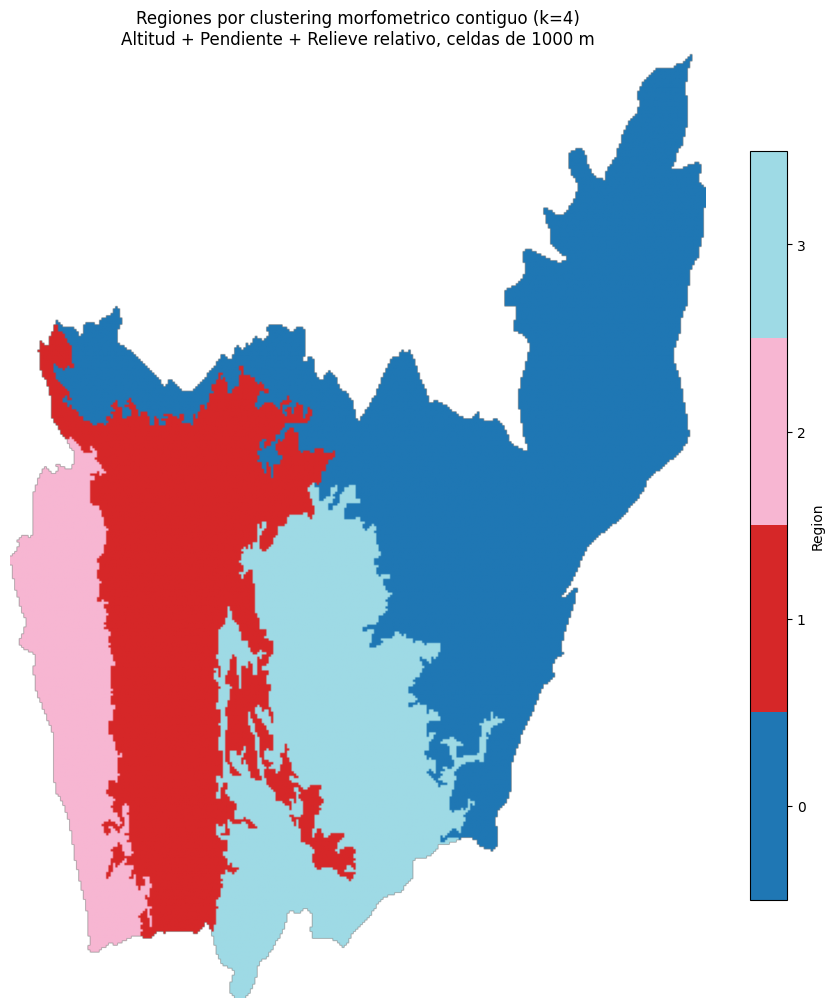

In [12]:
regiones_agg = np.full(mascara_agg_valida.shape, -1, dtype=np.int32)
regiones_agg_flat = regiones_agg.ravel()
regiones_agg_flat[indices_validos] = etiquetas_finales
regiones_agg = regiones_agg_flat.reshape(mascara_agg_valida.shape)

transform_agg = rasterio.Affine(
    transform_original.a * FACTOR_AGREGACION, transform_original.b, transform_original.c,
    transform_original.d, transform_original.e * FACTOR_AGREGACION, transform_original.f,
)

regiones_visualizar = np.ma.masked_equal(regiones_agg, -1)
cmap_regiones = plt.get_cmap("tab20", K_REGIONES)

fig, ax = plt.subplots(figsize=(9, 11))
im = ax.imshow(regiones_visualizar, cmap=cmap_regiones, vmin=-0.5, vmax=K_REGIONES - 0.5)
ax.set_title(f"Regiones por clustering morfometrico contiguo (k={K_REGIONES})\n"
             f"Altitud + Pendiente + Relieve relativo, celdas de {FACTOR_AGREGACION*50} m")
ax.set_axis_off()
plt.colorbar(im, ax=ax, ticks=range(K_REGIONES), label="Region", shrink=0.7)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_RESULTADOS, "23_mapa_regiones_clustering.png"), dpi=150)
plt.show()

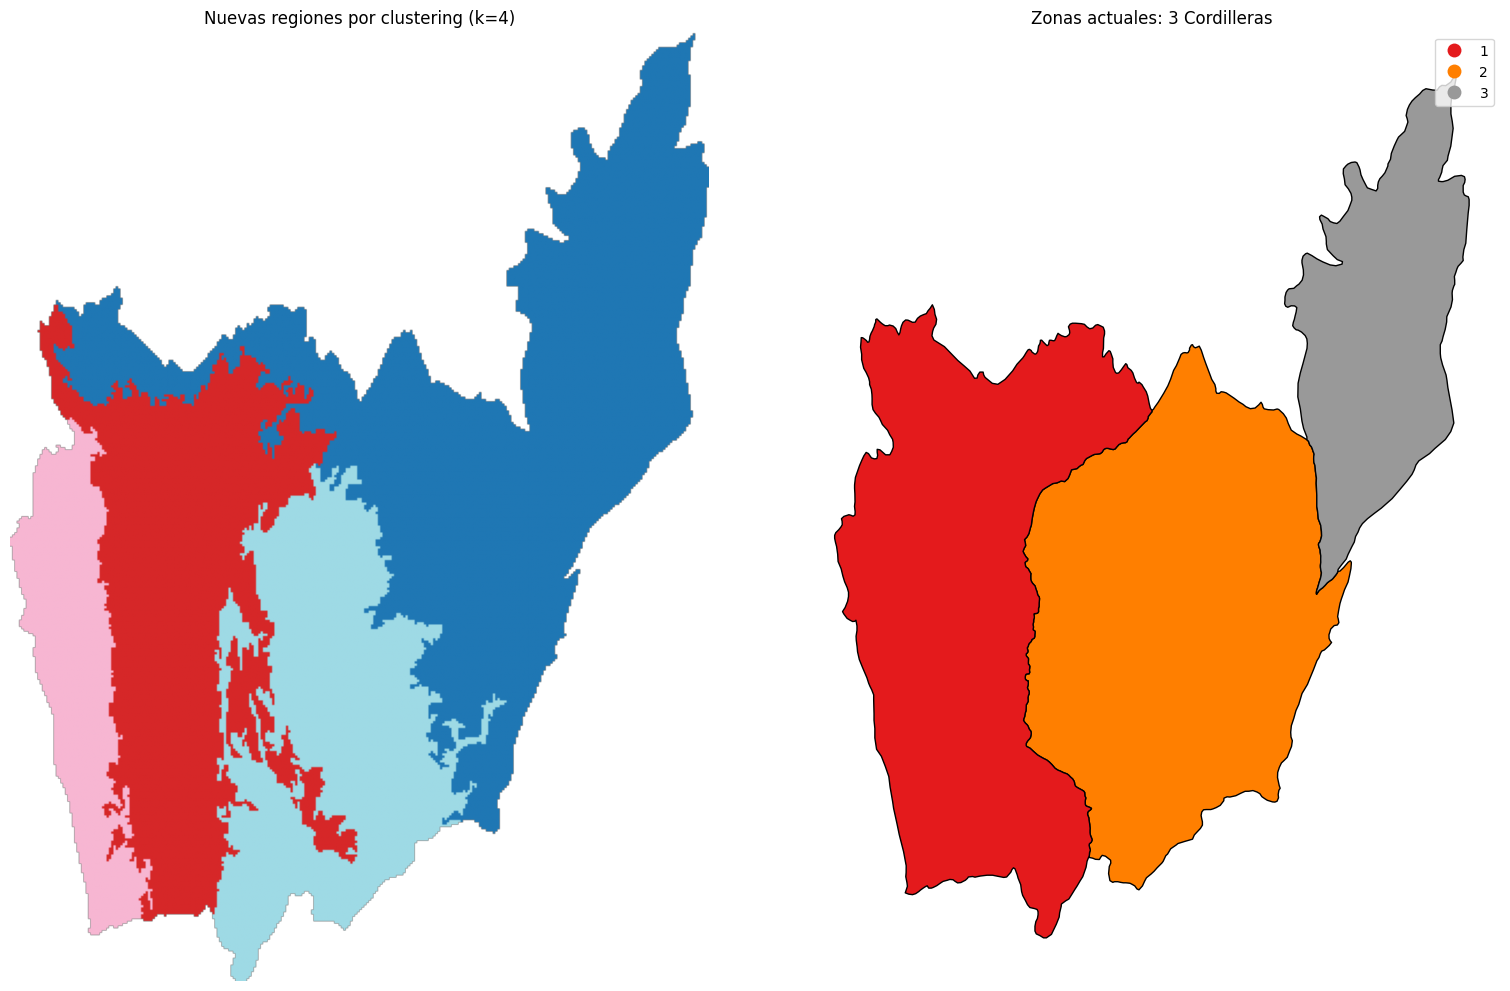

In [13]:
gdf_cordilleras = gpd.read_file(RUTA_CORDILLERAS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

ax1.imshow(regiones_visualizar, cmap=cmap_regiones, vmin=-0.5, vmax=K_REGIONES - 0.5)
ax1.set_title(f"Nuevas regiones por clustering (k={K_REGIONES})")
ax1.set_axis_off()

gdf_cordilleras.plot(column="Id", categorical=True, cmap="Set1", edgecolor="black", ax=ax2, legend=True)
ax2.set_title("Zonas actuales: 3 Cordilleras")
ax2.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_RESULTADOS, "24_comparacion_zonas_cordillera_vs_clustering.png"), dpi=150)
plt.show()

## 8. Exportar el raster de zonas a 50 m (reemplazo de `zonas_cordilleras.tif`)

La grilla agregada se reescala de vuelta a la resolucion original repitiendo cada celda
`FACTOR_AGREGACION x FACTOR_AGREGACION` veces (expansion de bloque exacta, sin
reproyeccion ni interpolacion, porque la agregacion fue un bloque uniforme limpio).

In [14]:
zonas_50m_recortado = np.repeat(np.repeat(regiones_agg, FACTOR_AGREGACION, axis=0), FACTOR_AGREGACION, axis=1)

zonas_50m = np.full(dem.shape, -1, dtype=np.int32)
zonas_50m[:filas_rec, :cols_rec] = zonas_50m_recortado

perfil_zonas = perfil_original.copy()
perfil_zonas.update(dtype="int32", nodata=-1, count=1)

RUTA_ZONAS = os.path.join(CARPETA_RESULTADOS, "zonas_clustering_regiones.tif")
with rasterio.open(RUTA_ZONAS, "w", **perfil_zonas) as dst:
    dst.write(zonas_50m, 1)

print(f"Zonas guardadas en: {RUTA_ZONAS}")
print(f"Pixeles con zona asignada: {(zonas_50m != -1).sum():,} de {zonas_50m.size:,} "
      f"({(zonas_50m != -1).mean()*100:.1f}%)")

Zonas guardadas en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\zonas_clustering_regiones.tif
Pixeles con zona asignada: 24,780,000 de 50,351,184 (49.2%)


## 9. Vectorizar las regiones (analogo a `Cordilleras.shp`)

Se vectoriza la grilla **agregada** (no los 50 m), para obtener poligonos limpios en vez
de un borde con escalones de pixel.

In [15]:
regiones_para_vectorizar = np.where(regiones_agg == -1, 0, regiones_agg + 1).astype(np.int32)
mascara_para_vectorizar = regiones_agg != -1

geometrias, valores = [], []
for geom, valor in rio_shapes(regiones_para_vectorizar, mask=mascara_para_vectorizar, transform=transform_agg):
    geometrias.append(shapely_shape(geom))
    valores.append(int(valor) - 1)

gdf_regiones = gpd.GeoDataFrame({"region": valores, "geometry": geometrias}, crs=crs_original)
gdf_regiones = gdf_regiones.dissolve(by="region", as_index=False)

RUTA_GPKG_REGIONES = os.path.join(CARPETA_RESULTADOS, "regiones_clustering.gpkg")
gdf_regiones.to_file(RUTA_GPKG_REGIONES, driver="GPKG")
print(f"Poligonos de regiones guardados en: {RUTA_GPKG_REGIONES} ({len(gdf_regiones)} regiones)")

Poligonos de regiones guardados en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\regiones_clustering.gpkg (4 regiones)


## 10. Validacion: ¿son estas regiones mas informativas que las 3 Cordilleras?

Se compara la proporcion de pixeles Altiplano por zona, igual que en
`05_modelo_jerarquico_cordilleras.ipynb` (figura `19_proporcion_altiplano_por_zona.png`),
pero ahora con la nueva zonificacion. Un rango mayor entre zonas (mas dispersion en la
proporcion de Altiplano) indica que la nueva zonificacion separa mejor el fenomeno de
interes, lo que la haria una mejor variable de agrupacion para el modelo jerarquico.

In [16]:
with rasterio.open(RUTA_ALTIPLANOS) as src:
    altiplanos_realineado = np.zeros(dem.shape, dtype=np.float32)
    reproject(
        source=rasterio.band(src, 1),
        destination=altiplanos_realineado,
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=transform_original, dst_crs=crs_original,
        resampling=Resampling.nearest,
    )
altiplanos_bin = (altiplanos_realineado == 1)

zonas_cordillera_raster = rasterize(
    [(geom, valor) for geom, valor in zip(gdf_cordilleras.geometry, gdf_cordilleras["Id"])],
    out_shape=dem.shape, transform=transform_original, fill=0, dtype="int32",
)


def proporcion_por_zona(zonas_raster, nombres_zona=None, zona_nodata=0):
    filas = []
    valores_zona = np.unique(zonas_raster[mascara_valida])
    for z in valores_zona:
        if z == zona_nodata:
            continue
        m = mascara_valida & (zonas_raster == z)
        filas.append({
            "zona": nombres_zona[z] if nombres_zona else int(z),
            "proporcion_altiplano": altiplanos_bin[m].mean(),
            "n_pixeles": int(m.sum()),
        })
    return pd.DataFrame(filas)


nombres_cordillera = {1: "Occidental", 2: "Central", 3: "SanLucas"}
tabla_cordillera = proporcion_por_zona(zonas_cordillera_raster, nombres_cordillera, zona_nodata=0)
tabla_regiones = proporcion_por_zona(zonas_50m, zona_nodata=-1)

print("Proporcion de Altiplano por Cordillera:")
print(tabla_cordillera.to_string(index=False))
print("\nProporcion de Altiplano por region (clustering):")
print(tabla_regiones.to_string(index=False))

rango_cordillera = tabla_cordillera["proporcion_altiplano"].max() - tabla_cordillera["proporcion_altiplano"].min()
rango_regiones = tabla_regiones["proporcion_altiplano"].max() - tabla_regiones["proporcion_altiplano"].min()
print(f"\nRango (max-min) de proporcion entre zonas -- Cordilleras (3 zonas): {rango_cordillera:.3f}")
print(f"Rango (max-min) de proporcion entre zonas -- Regiones clustering ({K_REGIONES} zonas): {rango_regiones:.3f}")

Proporcion de Altiplano por Cordillera:
      zona  proporcion_altiplano  n_pixeles
Occidental              0.038106    9849907
   Central              0.251769   10254315
  SanLucas              0.168659    4679744

Proporcion de Altiplano por region (clustering):
 zona  proporcion_altiplano  n_pixeles
    0              0.187754   10585381
    1              0.002376    6266407
    2              0.121482    2447929
    3              0.267908    5399690

Rango (max-min) de proporcion entre zonas -- Cordilleras (3 zonas): 0.214
Rango (max-min) de proporcion entre zonas -- Regiones clustering (4 zonas): 0.266


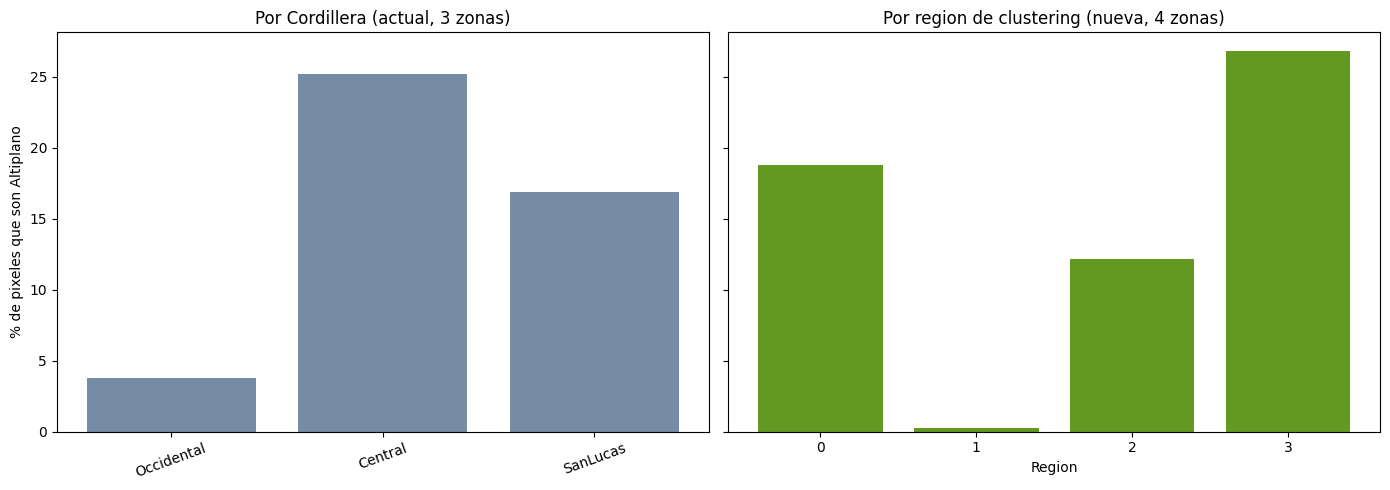


TIEMPO TOTAL DEL NOTEBOOK: 19.1s


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.bar(tabla_cordillera["zona"], tabla_cordillera["proporcion_altiplano"] * 100, color="#768CA4")
ax1.set_title("Por Cordillera (actual, 3 zonas)")
ax1.set_ylabel("% de pixeles que son Altiplano")
ax1.tick_params(axis="x", rotation=20)

ax2.bar(tabla_regiones["zona"].astype(str), tabla_regiones["proporcion_altiplano"] * 100, color="#639922")
ax2.set_title(f"Por region de clustering (nueva, {K_REGIONES} zonas)")
ax2.set_xlabel("Region")

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_RESULTADOS, "25_proporcion_altiplano_por_region_clustering.png"), dpi=150)
plt.show()

print(f"\nTIEMPO TOTAL DEL NOTEBOOK: {time.time()-t0_total:.1f}s")

## 11. Conclusiones y proximos pasos

- Este notebook produce `Resultados\zonas_clustering_regiones.tif` (mismo formato/grilla
  que `zonas_cordilleras.tif`) y `Resultados\regiones_clustering.gpkg` (analogo a
  `Cordilleras.shp`), listos para usarse como reemplazo directo de la variable de zona en
  `05_modelo_jerarquico_cordilleras.ipynb`.
- **Siguiente paso natural:** volver a ajustar el modelo jerarquico (efectos fijos +
  version bayesiana) usando esta nueva zonificacion en vez de las 3 Cordilleras, y comparar
  AUC/recall/precision y la varianza entre zonas (SD del intercepto aleatorio) contra los
  resultados ya documentados en `05_modelo_jerarquico_cordilleras.ipynb`.
- El factor de agregacion (`FACTOR_AGREGACION=20`, celdas de 1 km) y el umbral de validez
  (`UMBRAL_VALIDEZ=0.5`) son ajustables; una resolucion mas fina daria regiones con
  fronteras mas precisas a costa de mucho mas tiempo de computo.